In [1]:
import os
import numpy as np
import scanpy as sc
import anndata as ad
import pandas as pd

import scib_metrics
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection

import scvi
import torch

os.chdir('/storage1/fs1/jmillman/Active/DigitalTwin')
%matplotlib inline

/opt/conda/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/opt

# Integration method benchmark

In [2]:
# load rna data
adata_rna = sc.read_h5ad('checkpoints/multiome_rna.h5ad')
adata_rna

AnnData object with n_obs × n_vars = 69535 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'dataset', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_peaks', 'nFeature_peaks', 'RNA.weight', 'peaks.weight', 'wnn_clusters', 'barcode', 'UMAP_1', 'UMAP_2', 'merged_rna_clusters', 'cca_clusters', 'rpca_clusters', 'harmony_clusters', 'nCount_integrated.peaks', 'nFeature_integrated.peaks', 'nCount_GeneActivity', 'nFeature_GeneActivity', 'day', 'intjoint_clusters', 'celltype'
    var: 'vf_vst_counts.S2D1_mean', 'vf_vst_counts.S2D1_variance', 'vf_vst_counts.S2D1_variance.expected', 'vf_vst_counts.S2D1_variance.standardized', 'vf_vst_counts.S2D1_variable', 'vf_vst_counts.S2D1_rank', 'vf_vst_counts.S3D1_mean', 'vf_vst_counts.S3D1_variance', 'vf_vst_counts.S3D1_variance.expected', 'vf_vst_counts.S3D1_variance.standardized', 'vf_vst_counts.S3D1_variable', 'vf_vst_counts.S3D1_rank', 'vf_vst_counts.S4D2_mean', 'vf_v

In [3]:
import time

adata_rna.obsm["Unintegrated"] = adata_rna.obsm["X_pca"]

start = time.time()
bm = Benchmarker(
    adata_rna,
    batch_key="orig.ident",
    label_key="intjoint_clusters",
    embedding_obsm_keys=["X_pca", "X_harmony", "X_integrated.cca", 'X_integrated.rpca'],
    pre_integrated_embedding_obsm_key="X_pca",
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),
    n_jobs=-1,
)

bm.prepare()
bm.benchmark()
end = time.time()
print(f"Time: {int((end - start) / 60)} min {int((end - start) % 60)} sec") # Fig. S2C

Metrics:   0%|        | 0/10 [00:00<?, ?it/s, Bio conservation: isolated_labels]ERROR:2025-10-20 21:18:49,851:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/opt/conda/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/opt/conda/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/opt/conda/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 262, in _check_cuda_versions
    _version_check("cuSPARSE", cuda_versions.cusparse_get_version,
  File "/opt/conda/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 217, in _version_check
    raise RuntimeError(msg)
RuntimeError: Outdated cuSPARSE installation found.
Version JAX was built against: 12507
Minimum supported: 1210

Time: 22 min 28 sec


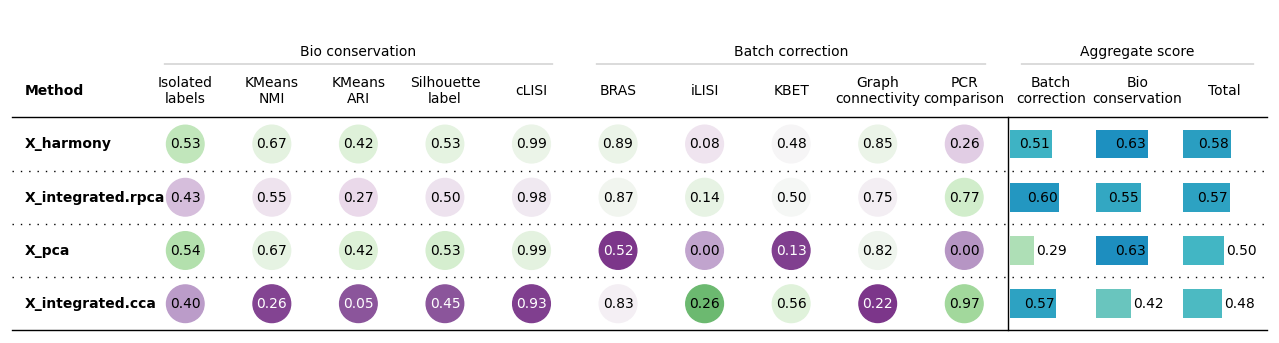

In [4]:
bm.plot_results_table() # Fig. S2C

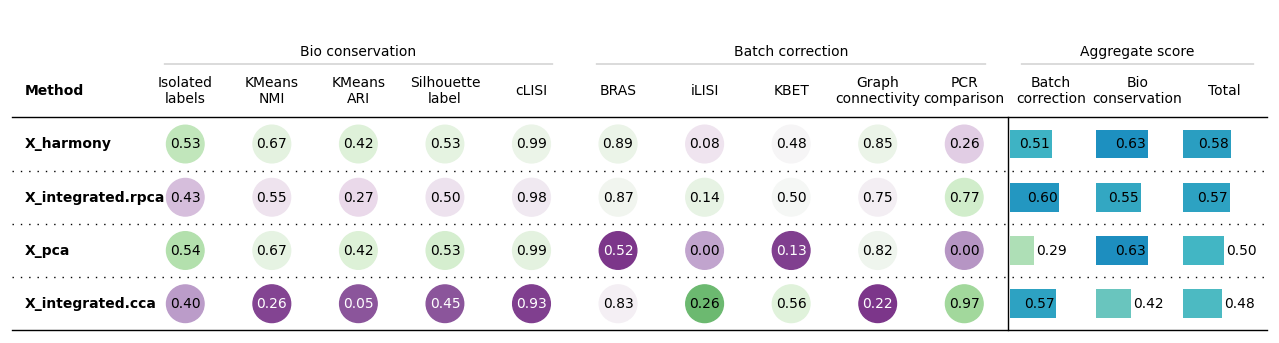

In [5]:
bm.plot_results_table(min_max_scale=False)

In [6]:
from rich import print

df = bm.get_results(min_max_scale=False)
print(df)

Isolated labels        KMeans NMI        KMeans ARI  \
Embedding                                                                 
X_pca                      0.537685          0.666487          0.423315   
X_harmony                  0.529394          0.672024           0.42167   
X_integrated.cca           0.404122          0.256915           0.05387   
X_integrated.rpca          0.428076          0.554459          0.272074   
Metric Type        Bio conservation  Bio conservation  Bio conservation   

                   Silhouette label             cLISI              BRAS  \
Embedding                                                                 
X_pca                       0.53339          0.993522          0.520443   
X_harmony                   0.52516          0.989775          0.885504   
X_integrated.cca           0.451556          0.928152          0.830513   
X_integrated.rpca          0.502174          0.977875          0.869848   
Metric Type        Bio conservation  Bio conservation  Batch correction   

                              iLISI              KBET Graph connectivity  \
Embedding                                                                  
X_pca                           0.0          0.129361           0.820742   
X_harmony                   0.07958          0.482826           0.846247   
X_integrated.cca           0.255688          0.563198           0.217969   
X_integrated.rpca          0.137277          0.495019           0.749594   
Metric Type        Batch correction  Batch correction   Batch correction   

                     PCR comparison Batch correction Bio conservation  \
Embedding                                                               
X_pca                           0.0         0.294109          0.63088   
X_harmony                  0.260609         0.510953         0.627605   
X_integrated.cca           0.973868         0.568247         0.418923   
X_integrated.rpca           0.77208         0.604764         0.546931   
Metric Type        Batch correction  Aggregate score  Aggregate score   

                             Total  
Embedding                           
X_pca                     0.496172  
X_harmony                 0.580944  
X_integrated.cca          0.478653  
X_integrated.rpca         0.570064  
Metric Type        Aggregate score